# Sistem Navigasi Kurir Last-Mile Delivery

Notebook ini berisi implementasi komputasional dan visualisasi analisis algoritma untuk penyelesaian masalah optimasi rute pada logistik *last-mile delivery*.

Terdapat dua fungsionalitas utama yang diuji dalam eksperimen ini:
1. Pathfinding (Pencarian Rute Tunggal): Membandingkan performa *Uniform Cost Search* (UCS), *Greedy Best-First Search* (GBFS), dan *A-Star* (A*).
2. TSP Routing (Rute Sirkuit Harian): Membandingkan performa pendekatan heuristik *Nearest Neighbor* (NNH) dengan algoritma eksak *Branch and Bound* (B&B).

[Link Google Colab](https://colab.research.google.com/drive/1NUZrYeYl5PFWUVsi5dDyZjMRdZbi4Gcf)

In [1]:
import math
import copy
import heapq

## Graph

Area operasional pengiriman dimodelkan menggunakan graf tak berarah  yang terdiri dari 12 simpul (*node*).
* Titik 1 sebagai Depot (titik awal keberangkatan kurir).
* Titik 2 hingga 12 sebagai lokasi pelanggan.

Jarak fisik antar-titik direpresentasikan menggunakan *Adjacency Matrix* (matriks ketetanggaan) dalam satuan meter. Nilai tak hingga ($\infty$) digunakan pada titik yang tidak memiliki jalur langsung, sedangkan untuk pendekatan heuristik, sistem menggunakan perhitungan jarak garis lurus (*Euclidean Distance*).

In [2]:
INF = 9999

NODE_NAMES = {
    0: "1 (Depot)", 1: "2", 2: "3", 3: "4",
    4: "5", 5: "6", 6: "7", 7: "8",
    8: "9", 9: "10", 10: "11", 11: "12"
}

NODE_COORDS = {
    0:  (400, 600),
    1:  (500, 650),
    2:  (900, 450),
    3:  (1000, 750),
    4:  (550, 950),
    5:  (480, 800),
    6:  (100, 850),
    7:  (150, 650),
    8:  (150, 400),
    9:  (0, 150),
    10: (300, 0),
    11: (400, 350)
}

adj_matrix = [
    #   1    2    3    4    5    6    7    8    9   10   11   12
    [   0, 200, INF, INF, INF, INF, INF, 300, INF, INF, INF, 200], # 1
    [ 200,   0, 300, INF, INF, 400, INF, INF, INF, INF, INF, INF], # 2
    [ INF, 300,   0, 200, INF, INF, INF, INF, INF, INF, INF, INF], # 3
    [ INF, INF, 200,   0, 200, INF, INF, INF, INF, INF, INF, INF], # 4
    [ INF, INF, INF, 200,   0, 200, INF, INF, INF, INF, INF, INF], # 5
    [ INF, 400, INF, INF, 200,   0, 250, INF, INF, INF, INF, INF], # 6
    [ INF, INF, INF, INF, INF, 250,   0, 200, INF, INF, INF, INF], # 7
    [ 300, INF, INF, INF, INF, INF, 200,   0, 200, INF, INF, INF], # 8
    [ INF, INF, INF, INF, INF, INF, INF, 200,   0, 200, 400, 300], # 9
    [ INF, INF, INF, INF, INF, INF, INF, INF, 200,   0, 250, 350], # 10
    [ INF, INF, INF, INF, INF, INF, INF, INF, 400, 250,   0, 200], # 11
    [ 200, INF, INF, INF, INF, INF, INF, INF, 300, 350, 200,   0], # 12
]

def get_heuristic(node, goal):
    x1, y1 = NODE_COORDS[node]
    x2, y2 = NODE_COORDS[goal]
    return round(math.sqrt((x1 - x2)**2 + (y1 - y2)**2), 2)

def get_neighbors(node):
    neighbors = []
    for j in range(len(adj_matrix[node])):
        if adj_matrix[node][j] != INF and adj_matrix[node][j] != 0:
            neighbors.append((j, adj_matrix[node][j]))
    return neighbors

## Implementasi Algoritma
* UCS
* GBFS
* A*
* BnB
* NNH

In [3]:
def ucs(start, goal, trace=False):
    pq = [(0, start, [start])]
    visited = set()
    explored_order = []

    if trace:
        print(f"\n[UCS] Mencari rute: {NODE_NAMES[start]} -> {NODE_NAMES[goal]}")
        print(f"{'Step':<6} {'Node Ekspansi':<15} {'Cost (g)':<10} {'Antrian (Cost:Node)'}")
    step = 1

    while pq:
        cost, node, path = heapq.heappop(pq)
        if node in visited: continue

        visited.add(node)
        explored_order.append(node)

        if node == goal:
            if trace: print(f"{step:<6} {NODE_NAMES[node]:<15} {cost:<10} [GOAL REACHED]")
            return path, cost, explored_order

        for neighbor, weight in get_neighbors(node):
            if neighbor not in visited:
                heapq.heappush(pq, (cost + weight, neighbor, path + [neighbor]))

        if trace:
            q_str = "[" + ", ".join([f"{item[0]}:{NODE_NAMES[item[1]].split()[0]}" for item in pq[:3]])
            if len(pq) > 3: q_str += "...]"
            elif not pq: q_str += "[]"
            else: q_str += "]"
            print(f"{step:<6} {NODE_NAMES[node]:<15} {cost:<10} {q_str}")
            step += 1

    return None, INF, explored_order

def gbfs(start, goal, trace=False):
    pq = [(get_heuristic(start, goal), start, 0, [start])]
    visited = set()
    explored_order = []

    if trace:
        print(f"\n[GBFS] Mencari rute: {NODE_NAMES[start]} -> {NODE_NAMES[goal]}")
        print(f"{'Step':<6} {'Node Ekspansi':<15} {'Heuristik(h)':<14} {'Cost(g)'}")
    step = 1

    while pq:
        h, node, cost, path = heapq.heappop(pq)
        if node in visited: continue
        visited.add(node)
        explored_order.append(node)

        if node == goal:
            if trace: print(f"{step:<6} {NODE_NAMES[node]:<15} {h:<14.1f} {cost} (GOAL)")
            return path, cost, explored_order

        for neighbor, weight in get_neighbors(node):
            if neighbor not in visited:
                heapq.heappush(pq, (get_heuristic(neighbor, goal), neighbor, cost + weight, path + [neighbor]))

        if trace:
            print(f"{step:<6} {NODE_NAMES[node]:<15} {h:<14.1f} {cost}")
            step += 1

    return None, INF, explored_order

def astar(start, goal, trace=False):
    pq = [(get_heuristic(start, goal), start, 0, [start])]
    visited = set()
    explored_order = []

    if trace:
        print(f"\n[A*] Mencari rute: {NODE_NAMES[start]} -> {NODE_NAMES[goal]}")
        print(f"{'Step':<6} {'Node Ekspansi':<15} {'f(n)=g+h':<10} {'g(n)':<10}")
    step = 1

    while pq:
        f, node, g, path = heapq.heappop(pq)
        if node in visited: continue
        visited.add(node)
        explored_order.append(node)

        if node == goal:
            if trace: print(f"{step:<6} {NODE_NAMES[node]:<15} {f:<10.1f} {g:<10} (GOAL)")
            return path, g, explored_order

        for neighbor, weight in get_neighbors(node):
            if neighbor not in visited:
                g_new = g + weight
                f_new = g_new + get_heuristic(neighbor, goal)
                heapq.heappush(pq, (f_new, neighbor, g_new, path + [neighbor]))

        if trace:
            print(f"{step:<6} {NODE_NAMES[node]:<15} {f:<10.1f} {g:<10}")
            step += 1

    return None, INF, explored_order

def reduce_matrix(matrix):
    mat = copy.deepcopy(matrix)
    n = len(mat)
    lb = 0
    for i in range(n):
        row = [mat[i][j] for j in range(n) if mat[i][j] != INF]
        if row:
            m = min(row)
            lb += m
            for j in range(n):
                if mat[i][j] != INF: mat[i][j] -= m
    for j in range(n):
        col = [mat[i][j] for i in range(n) if mat[i][j] != INF]
        if col:
            m = min(col)
            lb += m
            for i in range(n):
                if mat[i][j] != INF: mat[i][j] -= m
    return mat, lb

def branch_and_bound(matrix, start, trace=False):
    n = len(matrix)
    initial_mat = copy.deepcopy(matrix)
    for i in range(n): initial_mat[i][i] = INF
    red_init, lb_init = reduce_matrix(initial_mat)
    pq = [(lb_init, 0, start, [start], red_init)]
    best_cost = INF
    best_route = None
    nodes_explored = 0

    if trace:
        print(f"\n[Branch & Bound] Memulai pencarian rute sirkuit optimal dari: {NODE_NAMES[start]}")
        print(f"{'Step':<6} {'Node Ekspansi':<15} {'Level':<7} {'Lower Bound':<13} {'Jalur Sementara'}")
    step = 1

    while pq:
        lb, level, curr_node, path, curr_mat = heapq.heappop(pq)
        nodes_explored += 1

        if trace:
            path_str = "[" + ", ".join([NODE_NAMES[x].split()[0] for x in path]) + "]"
            if len(path_str) > 30: path_str = path_str[:27] + "...]"
            print(f"{step:<6} {NODE_NAMES[curr_node]:<15} {level:<7} {lb:<13} {path_str}")
            step += 1

        if lb >= best_cost: continue

        if level == n - 1:
            return_cost = matrix[curr_node][start]
            if return_cost != INF:
                total = lb
                if total < best_cost:
                    best_cost = total
                    best_route = path + [start]
                    if trace: print(f"       >>> [SIRKUIT LENGKAP DITEMUKAN] Cost Baru: {best_cost}")
            continue

        for next_node in range(n):
            if next_node not in path and curr_mat[curr_node][next_node] != INF:
                nm = copy.deepcopy(curr_mat)
                edge_cost = curr_mat[curr_node][next_node]
                for k in range(n):
                    nm[curr_node][k] = INF
                    nm[k][next_node] = INF
                nm[next_node][start] = INF
                nm_reduced, red_lb = reduce_matrix(nm)
                new_lb = lb + edge_cost + red_lb
                if new_lb < best_cost:
                    heapq.heappush(pq, (new_lb, level + 1, next_node, path + [next_node], nm_reduced))

    return best_route, best_cost, nodes_explored


def nearest_neighbor(start, trace=False):
    n = len(adj_matrix)
    visited = [False] * n
    current = start
    visited[current] = True
    route = [current]
    total_cost = 0
    explored_nodes = [current]

    if trace:
        print(f"\n[Nearest Neighbor] Memulai rute sirkuit heuristik dari: {NODE_NAMES[start]}")
        print(f"{'Step':<6} {'Posisi Saat Ini':<18} {'-> Pindah Ke':<18} {'Cost (Jarak)'}")
    step = 1

    for _ in range(n - 1):
        best_cost = INF
        best_next = -1
        for j in range(n):
            if not visited[j] and adj_matrix[current][j] != INF and adj_matrix[current][j] != 0:
                if adj_matrix[current][j] < best_cost:
                    best_cost = adj_matrix[current][j]
                    best_next = j

        if best_next == -1: return None, INF, explored_nodes

        if trace:
            print(f"{step:<6} {NODE_NAMES[current]:<18} -> {NODE_NAMES[best_next]:<18} {best_cost} m")
            step += 1

        total_cost += best_cost
        visited[best_next] = True
        route.append(best_next)
        explored_nodes.append(best_next)
        current = best_next

    return_cost = adj_matrix[current][start]
    if return_cost != INF:
        total_cost += return_cost
        route.append(start)
        explored_nodes.append(start)
        if trace:
            print(f"{step:<6} {NODE_NAMES[current]:<18} -> {NODE_NAMES[start]:<18} {return_cost} m (Kembali ke Depot)")
    else: return None, INF, explored_nodes

    return route, total_cost, explored_nodes

## Eksekusi dan Visualisasi (Main)

Berikut ini fungsi *main* yang mengeksekusi seluruh algoritma. Proses ini akan melakukan *tracing* penelusuran status simpul dan mengekstrak metrik performa (Jarak, Total Evaluasi Node, dan Waktu Eksekusi) ke dalam bentuk grafik.


-----------------------------------------------------------------
             TRACING ALGORITMA PATHFINDING TITIK 2
-----------------------------------------------------------------

[UCS] Mencari rute: 1 (Depot) -> 2
Step   Node Ekspansi   Cost (g)   Antrian (Cost:Node)
1      1 (Depot)       0          [200:2, 300:8, 200:12]
2      2               200        [GOAL REACHED]

[GBFS] Mencari rute: 1 (Depot) -> 2
Step   Node Ekspansi   Heuristik(h)   Cost(g)
1      1 (Depot)       111.8          0
2      2               0.0            200 (GOAL)

[A*] Mencari rute: 1 (Depot) -> 2
Step   Node Ekspansi   f(n)=g+h   g(n)      
1      1 (Depot)       111.8      0         
2      2               200.0      200        (GOAL)
-----------------------------------------------------------------
             TRACING ALGORITMA PATHFINDING TITIK 3
-----------------------------------------------------------------

[UCS] Mencari rute: 1 (Depot) -> 3
Step   Node Ekspansi   Cost (g)   Antrian (Cost:Node)

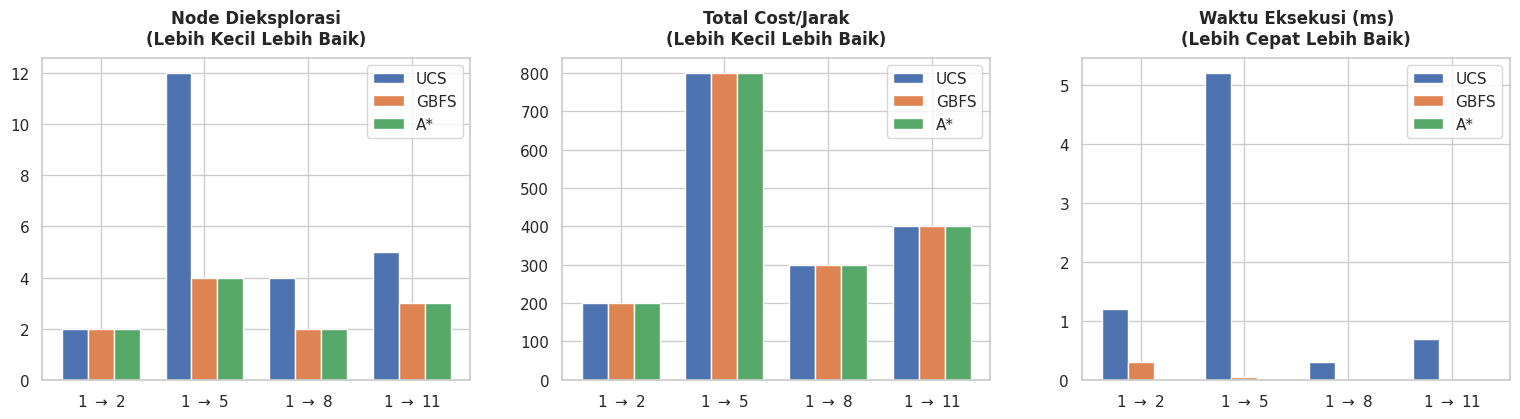

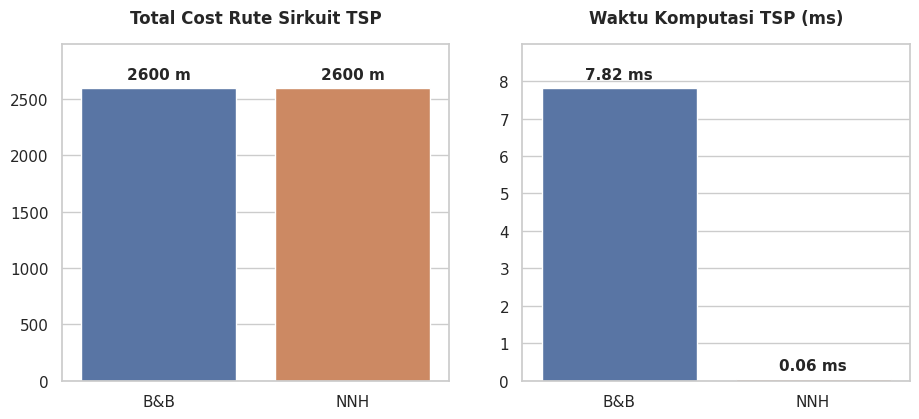

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")


# 1. TRACING TEXT

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 2")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 1 # Titik 2

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 3")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 2 # Titik 3

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 4")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 3 # Titik 4

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 5")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 4 # Titik 5

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 6")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 5 # Titik 6

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 7")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 6 # Titik 7

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 8")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 7 # Titik 8

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 9")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 8 # Titik 9

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)


print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 10")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 9 # Titik 10

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 11")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 10 # Titik 11

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("-" * 65)
print("             TRACING ALGORITMA PATHFINDING TITIK 12")
print("-" * 65)
titik_awal_trace = 0   # 1 (Depot)
titik_tujuan_trace = 11 # Titik 12

ucs(titik_awal_trace, titik_tujuan_trace, trace=True)
gbfs(titik_awal_trace, titik_tujuan_trace, trace=True)
astar(titik_awal_trace, titik_tujuan_trace, trace=True)

print("\n\n" + "-" * 65)
print("               TRACING ALGORITMA TSP")
print("-" * 65)
nearest_neighbor(titik_awal_trace, trace=True)
branch_and_bound(adj_matrix, titik_awal_trace, trace=True)

print("\n\n" + "=" * 65)
print("             MEMUAT GRAFIK PERBANDINGAN...")
print("=" * 65 + "\n")


# 2. DATA UNTUK GRAFIK (MANUAL DARI VS CODE)

labels = [
    r"1 $\rightarrow$ 2",
    r"1 $\rightarrow$ 5",
    r"1 $\rightarrow$ 8",
    r"1 $\rightarrow$ 11"
]

# Data Node Pathfinding
nodes_ucs   = [2, 12, 4, 5]
nodes_gbfs  = [2, 4, 2, 3]
nodes_astar = [2, 4, 2, 3]

# Data Cost Pathfinding / Jarak
cost_ucs   = [200, 800, 300, 400]
cost_gbfs  = [200, 800, 300, 400]
cost_astar = [200, 800, 300, 400]

# Waktu Pathfinding / ms
waktu_ucs   = [1.2, 5.2, 0.3, 0.7]
waktu_gbfs  = [0.3, 0.05, 0.01, 0.02]
waktu_astar = [0.02, 0.01, 0.007, 0.01]

# Data TSP (B&B vs NNH)
algos_tsp = ['B&B', 'NNH']
costs_tsp = [2600, 2600]
times_tsp = [7.82, 0.06]

# 3. VISUALISASI GRAFIK PATHFINDING

x = np.arange(len(labels))
width = 0.25

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Node Dieksplorasi
ax1.bar(x - width, nodes_ucs, width, label='UCS', color='#4C72B0')
ax1.bar(x, nodes_gbfs, width, label='GBFS', color='#DD8452')
ax1.bar(x + width, nodes_astar, width, label='A*', color='#55A868')
ax1.set_title('Node Dieksplorasi\n(Lebih Kecil Lebih Baik)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.legend()

# Total Cost / Jarak
ax2.bar(x - width, cost_ucs, width, label='UCS', color='#4C72B0')
ax2.bar(x, cost_gbfs, width, label='GBFS', color='#DD8452')
ax2.bar(x + width, cost_astar, width, label='A*', color='#55A868')
ax2.set_title('Total Cost/Jarak\n(Lebih Kecil Lebih Baik)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=11)
ax2.legend()

# Waktu Eksekusi
ax3.bar(x - width, waktu_ucs, width, label='UCS', color='#4C72B0')
ax3.bar(x, waktu_gbfs, width, label='GBFS', color='#DD8452')
ax3.bar(x + width, waktu_astar, width, label='A*', color='#55A868')
ax3.set_title('Waktu Eksekusi (ms)\n(Lebih Cepat Lebih Baik)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xticks(x)
ax3.set_xticklabels(labels, fontsize=11)
ax3.legend()

plt.tight_layout(pad=3.0)
plt.show()

# 4. VISUALISASI GRAFIK TSP ROUTING (B&B vs NNH)

fig, (ax4, ax5) = plt.subplots(1, 2, figsize=(10, 5))

# Total Cost TSP
sns.barplot(x=algos_tsp, y=costs_tsp, ax=ax4, hue=algos_tsp, palette=['#4C72B0', '#DD8452'], legend=False)
ax4.set_title('Total Cost Rute Sirkuit TSP', fontsize=12, fontweight='bold', pad=15)
ax4.set_ylim(0, max(costs_tsp) * 1.15)
for i, v in enumerate(costs_tsp):
    ax4.text(i, v + (max(costs_tsp) * 0.02), f'{v} m', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Waktu Komputasi TSP
sns.barplot(x=algos_tsp, y=times_tsp, ax=ax5, hue=algos_tsp, palette=['#4C72B0', '#DD8452'], legend=False)
ax5.set_title('Waktu Komputasi TSP (ms)', fontsize=12, fontweight='bold', pad=15)
ax5.set_ylim(0, max(times_tsp) * 1.15)
for i, v in enumerate(times_tsp):
    ax5.text(i, v + (max(times_tsp) * 0.02), f'{v:.2f} ms', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout(pad=3.0)
plt.show()